In [1]:
!pip -q install earthengine-api geemap geopandas rasterio shapely pyproj

import os, json, hashlib
import numpy as np
import pandas as pd

from google.colab import auth, drive
import ee, geemap


drive.mount('/content/drive')
auth.authenticate_user()
ee.Initialize(project='ee-nmajeed7811')
print("✅ EE initialized")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.5 MB/s eta 0:00:00
Mounted at /content/drive
✅ EE initialized


In [ ]:
# ---- AOI ----
aoi_asset_path = 'projects/ee-nmajeed7811/assets/Len_4326'
aoi_fc = ee.FeatureCollection(aoi_asset_path)
aoi = aoi_fc.geometry()
print("✅ AOI loaded:", aoi.type().getInfo())

# ---- SEB multiband asset (10 m) ----
seb_asset_id = 'projects/ee-nmajeed7811/assets/SEB_INPUTS_WC_Landsat_30m_2024_08_Corrected'

seb_img = ee.Image(seb_asset_id).clip(aoi)

band_names = seb_img.bandNames().getInfo()
print("✅ SEB bands:", len(band_names))
print("First bands:", band_names[:15])

REQ = ['wc', 'alb_ls', 'absorp_ls', 'emis_ls']
missing = [b for b in REQ if b not in band_names]
if missing:
    raise ValueError(f"Missing required bands: {missing}\nAvailable: {band_names}")

print("✅ Required bands exist:", REQ)


✅ AOI loaded: MultiPolygon
✅ SEB bands: 9
First bands: ['wc', 'alb_ls', 'absorp_ls', 'emis_ls', 'z0m', 'rho', 'cp', 'lambda', 'rhoCp']
✅ Required bands exist: ['wc', 'alb_ls', 'absorp_ls', 'emis_ls']


In [ ]:
EXPORT_BANDS = ['wc', 'alb_ls', 'absorp_ls', 'emis_ls']

def add_lonlat(feat):
    pt = ee.Feature(feat).geometry().centroid()
    coords = pt.coordinates()
    return (ee.Feature(feat)
            .set({'longitude': coords.get(0), 'latitude': coords.get(1)})
            .setGeometry(None))

samples = (seb_img
           .select(EXPORT_BANDS)
           .sample(region=aoi, scale=30, geometries=True, tileScale=4)
           .map(add_lonlat))

export_cols = ['longitude', 'latitude'] + EXPORT_BANDS

target_date = "2024-08-09"
OVERPASS_HOUR = 10

desc = f"pixel_data_SEBasset_{target_date}_30m_WCclass_Landsat_alpha_eps_corrected"

task = ee.batch.Export.table.toDrive(
    collection=samples.select(export_cols),
    description=desc,
    folder='EE_exports',
    fileFormat='CSV',
    selectors=export_cols
)
task.start()
print(f"✅ Export started: Drive/EE_exports/{desc}.csv")


✅ Export started: Drive/EE_exports/pixel_data_SEBasset_2024-08-09_30m_WCclass_Landsat_alpha_eps_corrected.csv


In [ ]:
csv_path = f"/content/drive/MyDrive/EE_exports/{desc}.csv"
print("🔎 Looking for:", csv_path)

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "CSV not found in Drive yet.\n"
        "Open Drive → EE_exports → confirm the export finished, then rerun this cell."
    )

pix = pd.read_csv(csv_path)
print("✅ pix loaded:", pix.shape)
display(pix.head())

# Ensure correct dtypes
pix['wc'] = pd.to_numeric(pix['wc'], errors='coerce').fillna(-999).astype(int)


🔎 Looking for: /content/drive/MyDrive/EE_exports/pixel_data_SEBasset_2024-08-09_30m_WCclass_Landsat_alpha_eps_corrected.csv
✅ pix loaded: (16584, 6)


,longitude,latitude,wc,alb_ls,absorp_ls,emis_ls
0,11.968435,45.372735,50,0.162458,0.837542,0.984767
1,11.968818,45.372725,50,0.146720,0.853280,0.990000
2,11.969200,45.372715,50,0.119552,0.880448,0.990000
3,11.969583,45.372705,50,0.127717,0.872283,0.990000
4,11.967656,45.372485,30,0.174055,0.825945,0.987282


In [ ]:
wx_path = '/content/drive/MyDrive/WeatherFile_Legnaro_ARPAV_with Date and Hours split.csv'
wx = pd.read_csv(wx_path)

wx['datetime'] = pd.to_datetime(wx['Date_only'], format='%d/%m/%Y') + pd.to_timedelta(wx['Hour'], unit='h')
wx = wx.set_index('datetime').sort_index()

need = ['Tair_K', 'Global radiation(W/m2)', 'Air Temp. At 2m (celcius)']
missing = [c for c in need if c not in wx.columns]
if missing:
    raise ValueError(f"Weather file missing columns: {missing}")

wx['Ta_C'] = wx['Air Temp. At 2m (celcius)']

# Sky temperature proxy (Kelvin)
wx['Tsky_K_derived'] = 0.0552 * (wx['Tair_K'] ** 1.5)

def kusuda_full(airC: pd.Series, depth_m: float, alpha_m2s: float) -> pd.Series:
    monthly = airC.resample('ME').mean()
    if len(monthly) < 12:
        return pd.Series(airC.mean(), index=airC.index, name='Tg_C')

    omega = 2*np.pi/(365*24*3600)
    k = np.sqrt(omega/(2*alpha_m2s))
    t_shift = 35*24*3600

    t_seconds = (airC.index - airC.index[0].normalize() + pd.Timedelta(days=1)).total_seconds()
    T_amp = monthly.max() - monthly.min()
    T_mean = airC.mean()

    Tg = T_mean - (T_amp/2.0) * np.exp(-k*depth_m) * np.cos(omega*(t_seconds - t_shift) - k*depth_m)
    return pd.Series(Tg, index=airC.index, name='Tg_C')

# Kusuda params (deep ground)
depth_m_k = 2.0
lam = 0.6
rho_g_k = 1200.0
Cg_k = 1670.0
alpha_m2s = lam / (rho_g_k * Cg_k)

wx['Tgk_C'] = kusuda_full(wx['Ta_C'], depth_m_k, alpha_m2s)
wx['Tgk_K'] = wx['Tgk_C'] + 273.15

sat_datetime = pd.to_datetime(f'{target_date} {OVERPASS_HOUR:02d}:00:00')
day_start = sat_datetime.floor('D')

wx_day = wx.loc[day_start:sat_datetime].copy()
if wx_day.empty:
    raise ValueError("No weather found for day → overpass window.")

TaK_arr  = wx_day['Tair_K'].to_numpy(np.float32)
I_arr    = wx_day['Global radiation(W/m2)'].to_numpy(np.float32)
Tsky_arr = wx_day['Tsky_K_derived'].to_numpy(np.float32)
TgK_arr  = wx_day['Tgk_K'].to_numpy(np.float32)

n_hours = len(wx_day)
print(f"✅ Forcing arrays: n_hours={n_hours}, from {wx_day.index[0]} → {wx_day.index[-1]}")
print("Shapes:", TaK_arr.shape, I_arr.shape, Tsky_arr.shape, TgK_arr.shape)


✅ Forcing arrays: n_hours=11, from 2024-08-09 00:00:00 → 2024-08-09 10:00:00
Shapes: (11,) (11,) (11,) (11,)


In [ ]:
alpha_vec = np.nan_to_num(pix['absorp_ls'].to_numpy(np.float32), nan=0.90)
eps_vec   = np.nan_to_num(pix['emis_ls'  ].to_numpy(np.float32), nan=0.97)

alpha_vec = np.clip(alpha_vec, 0.0, 1.0)
eps_vec   = np.clip(eps_vec,   0.85, 0.999)

cls = pix['wc'].to_numpy(np.int32)
n_pix = cls.size

classes_node1 = {}
classes_node2 = {0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100} # Added missing classes to node2

mask1 = np.isin(cls, list(classes_node1))
mask2 = np.isin(cls, list(classes_node2))

if np.any(~(mask1|mask2)):
    bad = np.unique(cls[~(mask1|mask2)]).tolist()
    raise ValueError(f"Unknown classes present (not in node1/node2 sets): {bad}")

idx1 = np.where(mask1)[0]
idx2 = np.where(mask2)[0]

print("✅ Hybrid split:")
print(" Node-1 pixels:", idx1.size, "classes:", sorted(classes_node1))
print(" Node-2 pixels:", idx2.size, "classes:", sorted(classes_node2))

✅ Hybrid split:
 Node-1 pixels: 0 classes: []
 Node-2 pixels: 16584 classes: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]


In [ ]:
# ============================
# TOP LAYER PROPERTIES BY CLASS
# ============================
# Units:
#   lam:  W/m/K
#   rho:  kg/m3
#   cp:   J/kg/K
#
# These are EXAMPLES. Replace with your own calibrated/assumed values.

# 0 fallback
# 10 tree
# 20 shrub
# 30 grass
# 40 crop
# 50 built-up
# 60 bare
# 70 snow/ice
# 80 water
# 90 wetland
# 95 mangroves
# 100 moss/lichen


CLASS_TOP = {
    0: dict(lam=2.00, rho=2100.0, cp=1000.0),
    10: dict(lam=0.6, rho=1300, cp=1800),
    20: dict(lam=0.6, rho=1300.0, cp=1800),
    30: dict(lam=0.6, rho=1300.0, cp= 1800),
    40: dict(lam=0.6, rho=1300.0, cp=1800),
    50: dict(lam=2.00,  rho=2100.0, cp=1000.0),
    60: dict(lam=0.6,  rho=1300.0, cp=1800.0),
    70: dict(lam=0.6,  rho=1300.0, cp=1800.0),
    80: dict(lam=0.6,  rho=1300.0, cp=1800.0),
    90: dict(lam=0.6,  rho=1300.0, cp=1800.0),
}

# Build per-pixel vectors from class map
lam_top_vec  = np.empty(n_pix, dtype=np.float32)
rhoCp_top_vec = np.empty(n_pix, dtype=np.float32)

for k, p in CLASS_TOP.items():
    m = (cls == k)
    if not np.any(m):
        continue
    lam_top_vec[m]   = np.float32(p['lam'])
    rhoCp_top_vec[m] = np.float32(p['rho'] * p['cp'])

# Verify all classes covered
uncovered = np.setdiff1d(np.unique(cls), np.array(list(CLASS_TOP.keys()), dtype=np.int32))
if uncovered.size:
    raise ValueError(f"Missing CLASS_TOP definitions for classes: {uncovered.tolist()}")

lam_top_vec = np.maximum(lam_top_vec, 1e-6)

print("✅ Top-layer vectors built from class constants.")
print("lambda stats:", float(np.min(lam_top_vec)), float(np.mean(lam_top_vec)), float(np.max(lam_top_vec)))
print("rhoCp stats:", float(np.min(rhoCp_top_vec)), float(np.mean(rhoCp_top_vec)), float(np.max(rhoCp_top_vec)))


✅ Top-layer vectors built from class constants.
lambda stats: 0.6000000238418579 0.8590811491012573 2.0
rhoCp stats: 2100000.0 2295586.0 2340000.0


In [ ]:
SIGMA32 = np.float32(5.670374419e-8)

# ---------------------------
# Node-1 (roof slab, 1-node)
# ---------------------------
Tindoor_K = np.float32(26.0 + 273.15)

Zc_roof = np.float32(0.10)   # roof effective thickness (model choice)
h_out32 = np.float32(15.0)   # outside convection (constant unless modeled)
h_in32  = np.float32(8.0)    # inside convection (constant unless modeled)

# TOP layer from class constants
HC_roof_vec = (rhoCp_top_vec * Zc_roof).astype(np.float32)                      # J/m2/K per pixel
R_roof_vec  = (Zc_roof / lam_top_vec + 1.0 / h_in32).astype(np.float32)         # m2K/W per pixel

# ---------------------------
# Node-2 (2-node surface + deep fixed)
# ---------------------------
Zc   = np.float32(0.10)   # top layer thickness (model choice)
Zg   = np.float32(1.0)
Zg_k = np.float32(1.0)

# Deep layer FIXED constants (as you requested)
rho_g_fix = np.float32(1200.0)
Cp_g_fix  = np.float32(1670.0)
lam_g_fix = np.float32(1.5)

h_c32 = np.float32(15.0)  # outside convection for node-2 surface

# TOP layer from class constants
Cc_vec  = (rhoCp_top_vec * Zc).astype(np.float32)                               # J/m2/K per pixel
Rth_vec = (Zc / lam_top_vec + Zg / lam_g_fix).astype(np.float32)                # m2K/W per pixel (top uses class λ, deep fixed)

# Deep capacity and resistance are fixed
Cg32    = np.float32(rho_g_fix * (Zg + Zg_k) * Cp_g_fix)
Rth_k32 = np.float32(Zg_k / lam_g_fix)

print("✅ Params ready.")


✅ Params ready.


In [ ]:
STATE_PATH = "/content/drive/MyDrive/EE_exports/TsTg_state_HYBRID_classconst_toplayer_WC_Landsat.npz"

def _hash_bytes(x: np.ndarray) -> str:
    h = hashlib.md5()
    h.update(np.ascontiguousarray(x).tobytes())
    return h.hexdigest()

PIX_FP  = hashlib.md5(cls.tobytes() + alpha_vec.tobytes() + eps_vec.tobytes()).hexdigest()
MASK1_FP = _hash_bytes(mask1.astype(np.uint8))
MASK2_FP = _hash_bytes(mask2.astype(np.uint8))

Ts = None
Tg = None

if os.path.exists(STATE_PATH):
    try:
        st = np.load(STATE_PATH, allow_pickle=True)
        meta = json.loads(str(st['meta'].item()))
        ok = (meta.get('pix_fp') == PIX_FP and meta.get('mask1_fp') == MASK1_FP and meta.get('mask2_fp') == MASK2_FP
              and meta.get('n_pix') == int(n_pix))
        if ok and ('Ts' in st) and ('Tg' in st):
            last_time = pd.to_datetime(meta['last_time'])
            if last_time < sat_datetime:
                Ts = st['Ts'].astype(np.float32).copy()
                Tg = st['Tg'].astype(np.float32).copy()
                print(f"🔁 Warm start from {last_time}")
    except Exception as e:
        print("⚠️ Could not load state:", e)

if Ts is None:
    Ts = np.full(n_pix, np.float32(TaK_arr[0]), dtype=np.float32)
if Tg is None:
    Tg = np.full(n_pix, np.float32(TgK_arr[0]), dtype=np.float32)

print("✅ State initialized.")


✅ State initialized.


In [ ]:
# Diagnostics (final substep only)
last_Rsw = np.full(n_pix, np.nan, dtype=np.float32)
last_Rlw = np.full(n_pix, np.nan, dtype=np.float32)
last_H   = np.full(n_pix, np.nan, dtype=np.float32)

last_G_int = np.full(n_pix, np.nan, dtype=np.float32)  # node-1 interior flux
last_Stor1 = np.full(n_pix, np.nan, dtype=np.float32)

last_Gcg   = np.full(n_pix, np.nan, dtype=np.float32)
last_Gk    = np.full(n_pix, np.nan, dtype=np.float32)
last_StorC = np.full(n_pix, np.nan, dtype=np.float32)
last_StorG = np.full(n_pix, np.nan, dtype=np.float32)

# Time stepping
tau_s  = 3600.0
N_SUB  = 50
dt_sub = np.float32(tau_s / N_SUB)

print(f"✅ HYBRID integrate: {n_hours} hours × {N_SUB} substeps (dt={float(dt_sub):.1f}s)")

for h in range(n_hours):
    I_h    = np.float32(I_arr[h])
    Ta_h   = np.float32(TaK_arr[h])
    Tsky_h = np.float32(Tsky_arr[h])
    Tgk_h  = np.float32(TgK_arr[h])

    Tsky2 = Tsky_h * Tsky_h
    Tsky4 = Tsky2 * Tsky2

    for s in range(N_SUB):

        # -------- Node-1 (idx1): 1-node roof --------
        if idx1.size > 0:
            Ts1 = Ts[idx1]
            Ts1_2 = Ts1 * Ts1
            Ts1_4 = Ts1_2 * Ts1_2

            Rsw1 = alpha_vec[idx1] * I_h
            Rlw1 = eps_vec[idx1] * (SIGMA32 * (Tsky4 - Ts1_4))
            H1   = -h_out32 * (Ts1 - Ta_h)
            Gint = -(Ts1 - Tindoor_K) / R_roof_vec[idx1]

            flux1 = Rsw1 + Rlw1 + H1 + Gint
            Ts1_new = Ts1 + (dt_sub / HC_roof_vec[idx1]) * flux1

            if (h == n_hours - 1) and (s == N_SUB - 1):
                last_Rsw[idx1]   = Rsw1
                last_Rlw[idx1]   = Rlw1
                last_H[idx1]     = H1
                last_G_int[idx1] = Gint
                last_Stor1[idx1] = -HC_roof_vec[idx1] * (Ts1_new - Ts1) / dt_sub

            Ts[idx1] = Ts1_new

        # -------- Node-2 (idx2): 2-node surface + deep --------
        if idx2.size > 0:
            Ts2 = Ts[idx2]
            Tg2 = Tg[idx2]

            Ts2_2 = Ts2 * Ts2
            Ts2_4 = Ts2_2 * Ts2_2

            Rsw2 = alpha_vec[idx2] * I_h
            Rlw2 = eps_vec[idx2] * (SIGMA32 * (Tsky4 - Ts2_4))
            H2   = -h_c32 * (Ts2 - Ta_h)

            Gcg = -(Ts2 - Tg2) / Rth_vec[idx2]    # top layer uses class λ
            Gk  = -(Tg2 - Tgk_h) / Rth_k32         # deep layer fixed

            dTs_dt = (Rsw2 + Rlw2 + H2 + Gcg) / Cc_vec[idx2]   # top layer uses class rhoCp
            dTg_dt = (-Gcg + Gk) / Cg32                        # deep capacity fixed

            Ts2_new = Ts2 + dt_sub * dTs_dt
            Tg2_new = Tg2 + dt_sub * dTg_dt

            if (h == n_hours - 1) and (s == N_SUB - 1):
                last_Rsw[idx2]   = Rsw2
                last_Rlw[idx2]   = Rlw2
                last_H[idx2]     = H2
                last_Gcg[idx2]   = Gcg
                last_Gk[idx2]    = Gk
                last_StorC[idx2] = Cc_vec[idx2] * dTs_dt
                last_StorG[idx2] = Cg32 * dTg_dt

            Ts[idx2] = Ts2_new
            Tg[idx2] = Tg2_new

print("✅ HYBRID finished.")


✅ HYBRID integrate: 11 hours × 50 substeps (dt=72.0s)
✅ HYBRID finished.


In [ ]:
meta = {
    "last_time": sat_datetime.isoformat(),
    "n_pix": int(n_pix),
    "pix_fp": PIX_FP,
    "mask1_fp": MASK1_FP,
    "mask2_fp": MASK2_FP,
    "model": "HYBRID_node1_classes123_node2_rest_classconst_toplayer_WC_Landsat",
    "note": "alpha/eps from asset, top-layer constants by class, deep fixed"
}
np.savez_compressed(STATE_PATH, Ts=Ts.astype(np.float32), Tg=Tg.astype(np.float32), meta=json.dumps(meta))
print("💾 State saved:", STATE_PATH)

pix['Ts_model_C'] = Ts.astype(np.float64) - 273.15

Tg_out = np.full(n_pix, np.nan, dtype=np.float64)
Tg_out[idx2] = Tg[idx2].astype(np.float64) - 273.15
pix['Tg_model_C'] = Tg_out

pix['Rsw_Wm2'] = last_Rsw.astype(np.float64)
pix['Rlw_Wm2'] = last_Rlw.astype(np.float64)
pix['H_Wm2']   = last_H.astype(np.float64)

pix['G_int_Wm2'] = last_G_int.astype(np.float64)
pix['G_cg_Wm2']  = last_Gcg.astype(np.float64)
pix['G_gk_Wm2']  = last_Gk.astype(np.float64)

pix['Storage_1node_Wm2'] = last_Stor1.astype(np.float64)
pix['Storage_c_Wm2']     = last_StorC.astype(np.float64)
pix['Storage_g_Wm2']     = last_StorG.astype(np.float64)

out_csv = f"/content/drive/MyDrive/EE_exports/pixel_data_{target_date}_HYBRID_classconst_toplayer_WC_Landsat.csv"
pix.to_csv(out_csv, index=False)
print("📦 Saved:", out_csv)

display(pix.head())


💾 State saved: /content/drive/MyDrive/EE_exports/TsTg_state_HYBRID_classconst_toplayer_WC_Landsat.npz
📦 Saved: /content/drive/MyDrive/EE_exports/pixel_data_2024-08-09_HYBRID_classconst_toplayer_WC_Landsat.csv


,longitude,latitude,wc,alb_ls,absorp_ls,emis_ls,Ts_model_C,Tg_model_C,Rsw_Wm2,Rlw_Wm2,H_Wm2,G_int_Wm2,G_cg_Wm2,G_gk_Wm2,Storage_1node_Wm2,Storage_c_Wm2,Storage_g_Wm2
0,11.968435,45.372735,50,0.162458,0.837542,0.984767,37.276971,17.006586,577.904114,-121.774300,-119.568329,NaN,-28.137432,-0.043121,NaN,308.424072,28.094311
1,11.968818,45.372725,50,0.146720,0.853280,0.990000,37.544397,17.007166,588.763062,-124.208786,-123.558655,NaN,-28.507816,-0.043991,NaN,312.487793,28.463825
2,11.969200,45.372715,50,0.119552,0.880448,0.990000,38.037317,17.008203,607.509033,-127.515724,-130.914459,NaN,-29.190630,-0.045547,NaN,319.888214,29.145082
3,11.969583,45.372705,50,0.127717,0.872283,0.990000,37.889154,17.007867,601.875305,-126.520050,-128.703461,NaN,-28.985424,-0.045044,NaN,317.666382,28.940380
4,11.967656,45.372485,30,0.174055,0.825945,0.987282,35.947931,16.997156,569.902283,-113.267471,-99.675751,NaN,-22.617956,-0.029160,NaN,334.341125,22.588797


✅ Ts GeoTIFF saved: /content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_2024-08-09_classconst_toplayer_wc_Landsat_30.tif
🌡️ Ts stats: 33.32903289794922 35.941505432128906 38.63610076904297


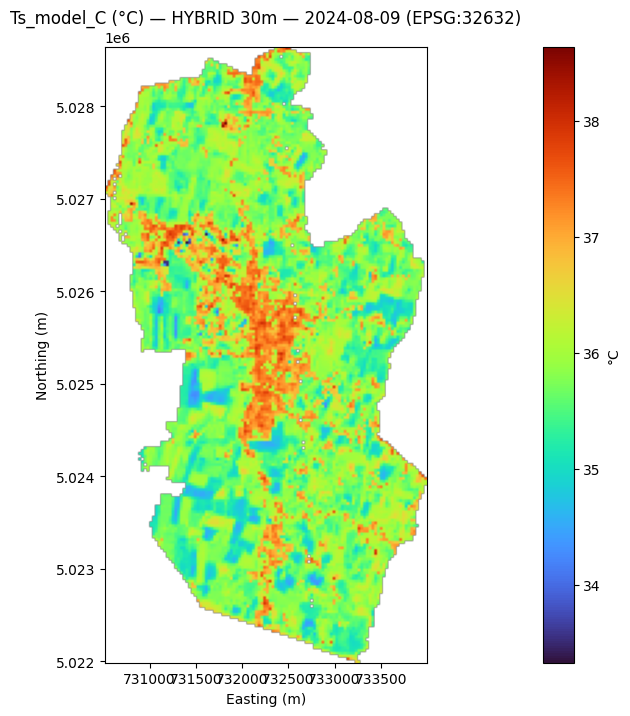

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from rasterio.crs import CRS
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

gdf = gpd.GeoDataFrame(
    pix,
    geometry=gpd.points_from_xy(pix.longitude, pix.latitude),
    crs="EPSG:4326"
).to_crs(32632) # Convert to EPSG:32632 for more consistent spatial representation

# Bounds are now in meters (EPSG:32632)
xmin, ymin, xmax, ymax = gdf.total_bounds

# Desired pixel size in meters
ps = 30

W = int(np.ceil((xmax - xmin) / ps))
H = int(np.ceil((ymax - ymin) / ps))

x = gdf.geometry.x.values
y = gdf.geometry.y.values

T = from_origin(xmin, ymax, ps, ps)

cols = ((x - xmin) / ps).astype(int)
rows = ((ymax - y) / ps).astype(int)

vals = gdf['Ts_model_C'].astype('float32').values
m = (cols >= 0) & (cols < W) & (rows >= 0) & (rows < H) & np.isfinite(vals)
cols, rows, vals = cols[m], rows[m], vals[m]

acc, ct = defaultdict(float), defaultdict(int)
for r, c, v in zip(rows, cols, vals):
    acc[(r, c)] += float(v)
    ct[(r, c)] += 1

rast = np.full((H, W), np.nan, dtype='float32')
for (r, c), s in acc.items():
    rast[r, c] = s / ct[(r, c)]

ts_tif = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif" # Updated filename for 32632
with rasterio.open(
    ts_tif, 'w',
    driver='GTiff',
    height=H, width=W,
    count=1,
    dtype='float32',
    crs=CRS.from_epsg(32632), # Changed CRS back to EPSG:32632
    transform=T,
    nodata=np.nan
) as dst:
    dst.write(rast, 1)

print("✅ Ts GeoTIFF saved:", ts_tif)
print("🌡️ Ts stats:", float(np.nanmin(rast)), float(np.nanmean(rast)), float(np.nanmax(rast)))

# -----------------------------
# Display the GeoTIFF (TURBO)
# -----------------------------
with rasterio.open(ts_tif) as src:
    img = src.read(1)
    bounds = src.bounds

img_masked = np.ma.masked_invalid(img)   # hide NaNs

plt.figure(figsize=(30, 8))
im = plt.imshow(
    img_masked,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
    cmap="turbo"
)
plt.title(f"Ts_model_C (°C) — HYBRID 30m — {target_date} (EPSG:32632)") # Updated title
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.colorbar(im, label="°C")
plt.show()

In [ ]:
!pip -q install geemap

import ee, geemap
import pandas as pd

# Make sure EE is initialized already (from your previous blocks):
# ee.Initialize(project='ee-nmajeed7811')

# ✅ Use the SAME AOI as your SEB/Ts pipeline
# If you already have `aoi` in memory from the SEB code, keep this:
# aoi_ls = aoi

# Otherwise load the same AOI asset:
AOI_ASSET = 'projects/ee-nmajeed7811/assets/Len_4326'
aoi_ls = ee.FeatureCollection(AOI_ASSET).geometry()
print("✅ AOI Landsat loaded:", aoi_ls.type().getInfo())

START_DATE = "2024-01-01"
END_DATE   = "2024-12-31"

# ----------------------------
# Landsat helpers
# ----------------------------
def mask_clouds_c2l2(img: ee.Image) -> ee.Image:
    qa = img.select("QA_PIXEL")
    m = (qa.bitwiseAnd(1 << 0).eq(0)
         .And(qa.bitwiseAnd(1 << 1).eq(0))
         .And(qa.bitwiseAnd(1 << 2).eq(0))
         .And(qa.bitwiseAnd(1 << 3).eq(0))
         .And(qa.bitwiseAnd(1 << 4).eq(0))
         .And(qa.bitwiseAnd(1 << 5).eq(0)))
    radsat = img.select("QA_RADSAT")
    m = m.And(radsat.eq(0))
    return img.updateMask(m)

def process_landsat_c2l2(img: ee.Image) -> ee.Image:
    # Scale SR
    scaled = img.select("SR_B.*").multiply(2.75e-05).subtract(0.2)
    img = img.addBands(scaled, None, True)

    # LST (Kelvin, Celsius) from ST_B10
    lst_k = img.select("ST_B10").multiply(0.00341802).add(149.0).rename("LST_K")
    lst_c = lst_k.subtract(273.15).rename("LST_C")

    # Albedo + Absorptance proxy (optional; not required for LST)
    albedo = img.expression(
        "((0.356*b)+(0.130*r)+(0.373*n)+(0.085*s1)+(0.072*s2)-0.018)/1.016",
        {
            "b":  img.select("SR_B2"),
            "r":  img.select("SR_B4"),
            "n":  img.select("SR_B5"),
            "s1": img.select("SR_B6"),
            "s2": img.select("SR_B7")
        }
    ).rename("albedo")
    absorp = ee.Image(1).subtract(albedo).rename("Absorptance")

    ndvi = img.normalizedDifference(["SR_B5", "SR_B4"]).rename("NDVI")
    return img.addBands([albedo, absorp, ndvi, lst_k, lst_c], None, True)

def add_emissivity_from_ndvi(img: ee.Image) -> ee.Image:
    ndvi = img.select("NDVI")
    Pv = (ndvi.subtract(0.2)
          .divide(0.3)
          .pow(2)
          .max(ee.Image.constant(0))
          .min(ee.Image.constant(1))
          .rename("Pv"))
    em_base = (Pv.multiply(0.99)
               .add(ee.Image.constant(1).subtract(Pv).multiply(0.97))
               .add(0.005)
               .clamp(0.90, 0.99)
               .rename("EM_base"))
    return img.addBands(ee.Image.cat([Pv, em_base]), None, True)

def prep_landsat(img0: ee.Image) -> ee.Image:
    footprint_mask = img0.select("ST_B10").mask()
    img = mask_clouds_c2l2(img0)
    img = process_landsat_c2l2(img)
    img = add_emissivity_from_ndvi(img)
    footprint_band = ee.Image.constant(1).rename("FOOTPRINT").updateMask(footprint_mask)
    return img.addBands(footprint_band, None, True)

def annotate_valid_fraction(img: ee.Image) -> ee.Image:
    scale = 30
    valid_count = ee.Number(
        img.select("LST_C").reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=aoi_ls,
            scale=scale,
            maxPixels=1e13,
            tileScale=2
        ).get("LST_C")
    )
    total_count = ee.Number(
        img.select("FOOTPRINT").reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=aoi_ls,
            scale=scale,
            maxPixels=1e13,
            tileScale=2
        ).get("FOOTPRINT")
    )
    frac = ee.Number(ee.Algorithms.If(total_count.gt(0), valid_count.divide(total_count), 0))
    return img.set({"validFrac": frac})

landsat8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
landsat9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

merged_with_frac = (landsat8.merge(landsat9)
                    .filterBounds(aoi_ls)
                    .filterDate(START_DATE, END_DATE)
                    .map(prep_landsat)
                    .map(annotate_valid_fraction))

print("✅ merged_with_frac ready.")


✅ AOI Landsat loaded: MultiPolygon
✅ merged_with_frac ready.


In [ ]:
def get_daily_collection(target_date: str) -> ee.ImageCollection:
    date_start = ee.Date(target_date)
    date_end   = date_start.advance(1, "day")
    return (merged_with_frac
            .filterDate(date_start, date_end)
            .filterBounds(aoi_ls))

def show_daily_median_on_map(target_date: str,
                             band: str = "LST_C",
                             vmin: float = 10,
                             vmax: float = 50):
    daily = get_daily_collection(target_date)
    n = daily.size().getInfo()
    print(f"Daily images on {target_date}: {n}")
    if n == 0:
        raise ValueError(f"No images found on {target_date} for your AOI.")

    daily_median = daily.median().clip(aoi_ls).set({"target_date": target_date})

    times = daily.aggregate_array("system:time_start").getInfo()
    times_fmt = [ee.Date(t).format("YYYY-MM-dd HH:mm").getInfo() for t in times]
    print("Acquisition times on this date:")
    for t in times_fmt:
        print("  -", t)

    # Turbo-like palette in EE (approx)
    vis = {"min": vmin, "max": vmax,
           "palette": ["30123b","4145ab","4675ed","39a2fc","1bcfd4","24eca6","7dff5a","d7f03a","f7b430","f1681d","b11607"]}

    m = geemap.Map()
    m.centerObject(aoi_ls, 12)
    m.addLayer(aoi_ls, {}, "AOI", True)
    m.addLayer(daily_median.select(band), vis, f"Daily MEDIAN {band} ({target_date})", True)

    # Best single image: highest validFrac, then lowest CLOUD_COVER
    best = ee.Image(daily.sort("validFrac", False).sort("CLOUD_COVER").first()).clip(aoi_ls)
    m.addLayer(best.select(band), vis, f"Best single {band} ({target_date})", False)

    stats = daily_median.select(band).reduceRegion(
        reducer=ee.Reducer.min().combine(ee.Reducer.mean(), "", True).combine(ee.Reducer.max(), "", True),
        geometry=aoi_ls,
        scale=30,
        maxPixels=1e13,
        tileScale=2
    ).getInfo()

    print(f"\n📊 Daily MEDIAN {band} stats over AOI:")
    print("  min :", stats.get(f"{band}_min"))
    print("  mean:", stats.get(f"{band}_mean"))
    print("  max :", stats.get(f"{band}_max"))

    return m, daily_median, best

target_date_new = "2024-08-09"

m, daily_median_img, best_img = show_daily_median_on_map(
    target_date=target_date_new,
    band="LST_C",
    vmin=10,
    vmax=50
)
m


Daily images on 2024-08-09: 2
Acquisition times on this date:
  - 2024-08-09 09:57
  - 2024-08-09 09:58

📊 Daily MEDIAN LST_C stats over AOI:
  min : 31.26053336000001
  mean: 37.438718860303396
  max : 49.44439976000001


Map(center=[45.342435778791994, 11.964714806126992], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
import geemap

# Export settings
EXPORT_FOLDER = "EE_exports"
crs_out = "EPSG:32632"
scale_out = 30

# Resample to 10m (bilinear) during export
best_lst_30m = best_img.select("LST_C").resample("bilinear").clip(aoi_ls)

desc = f"Landsat_LST_C_best_{target_date_new}_30m_32632_full_corrected"

task = ee.batch.Export.image.toDrive(
    image=best_lst_30m,
    description=desc,
    folder=EXPORT_FOLDER,
    fileNamePrefix=desc,
    region=aoi_ls,
    scale=scale_out,
    crs=crs_out,
    maxPixels=1e13
)
task.start()
print(f"✅ Export started: Drive/{EXPORT_FOLDER}/{desc}.tif")

# After it finishes, set the path like this:
lst_30m_tif = f"/content/drive/MyDrive/{EXPORT_FOLDER}/{desc}.tif"
print("➡️ Use this path later:", lst_30m_tif)


✅ Export started: Drive/EE_exports/Landsat_LST_C_best_2024-08-09_30m_32632_full_corrected.tif
➡️ Use this path later: /content/drive/MyDrive/EE_exports/Landsat_LST_C_best_2024-08-09_30m_32632_full_corrected.tif


✅ Residual stats (LST - Ts): -4.483680725097656 1.5498055219650269 13.13382339477539
✅ Saved residual raster: /content/drive/MyDrive/EE_exports/LST_minus_Ts_2024-08-09_30m_32632_Landsat.tif


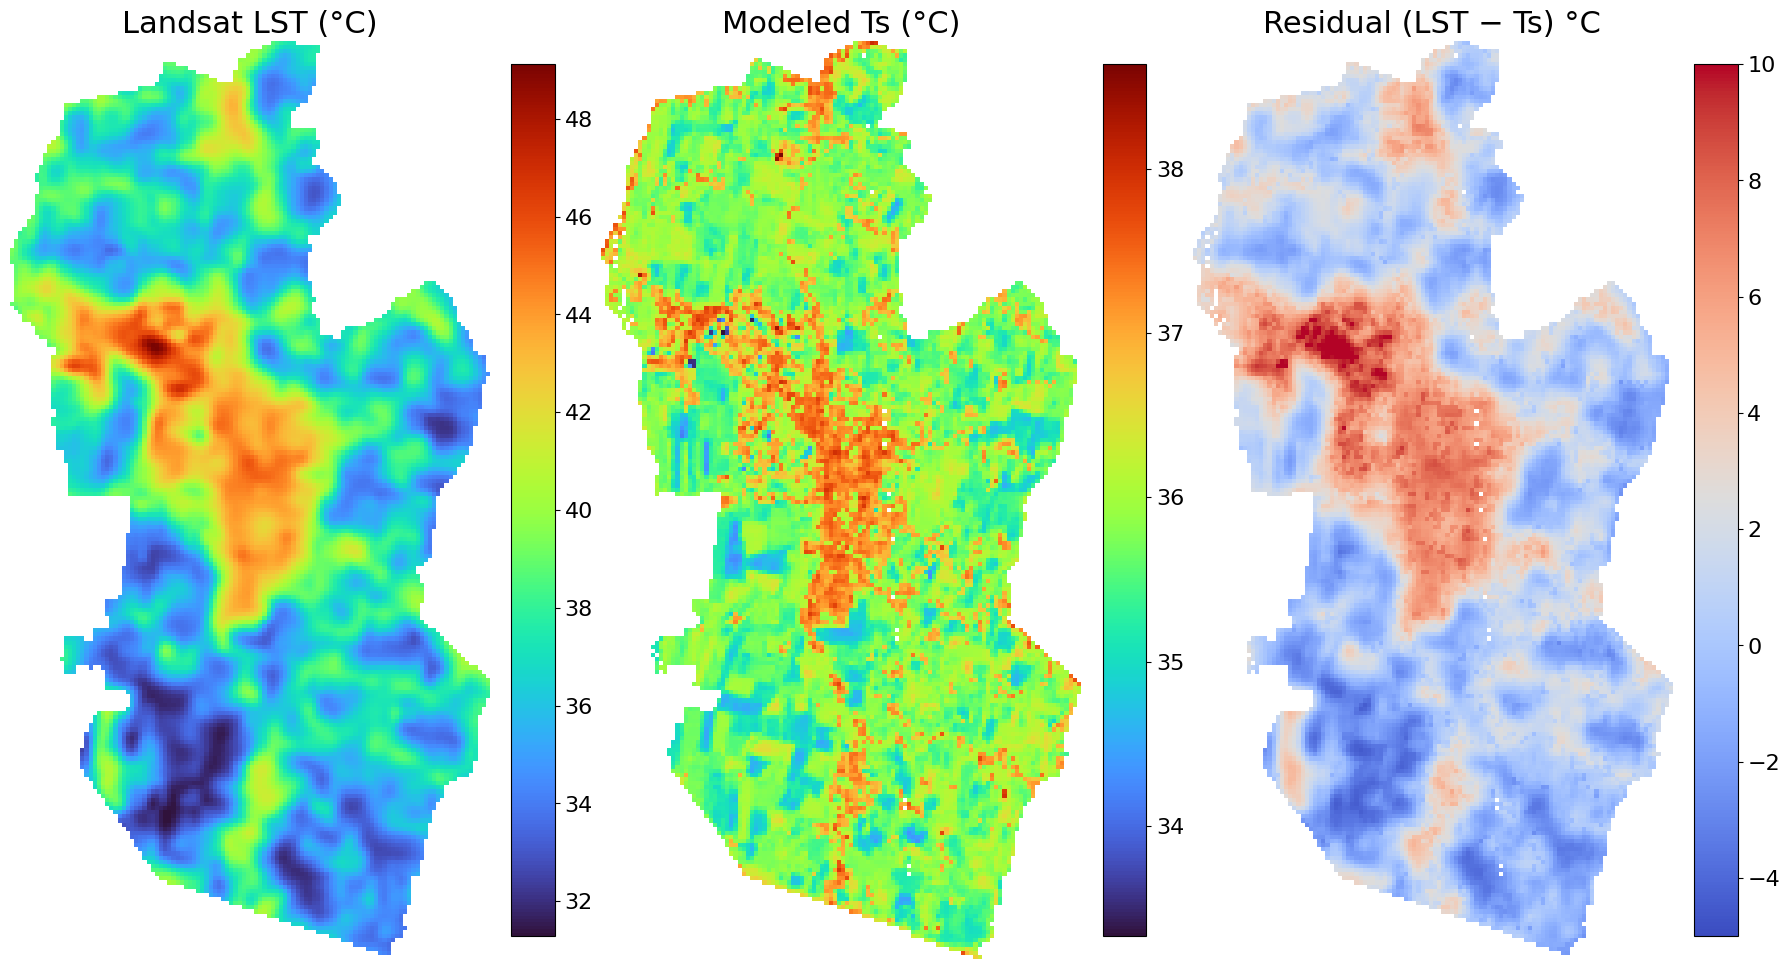

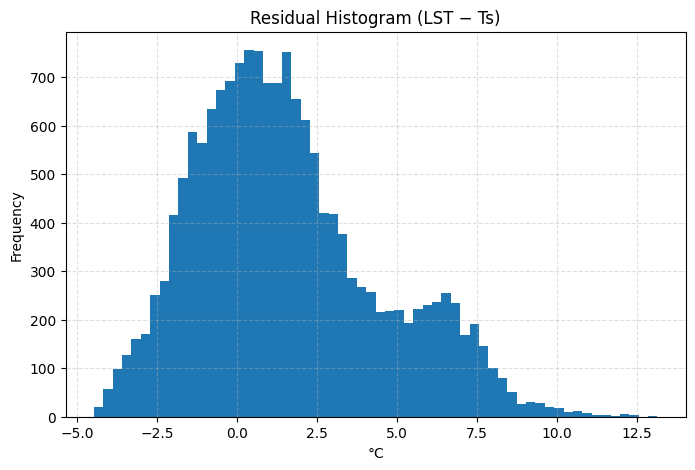

In [ ]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# ---- paths ----
# ✅ update to the new Ts filename you are producing
target_date = target_date_new  # keep consistent

ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif"
lst_tif = lst_30m_tif

# ---- read Ts (template grid) ----
with rasterio.open(ts_tif) as ts_src:
    Ts = ts_src.read(1).astype(np.float32)
    ts_profile = ts_src.profile
    ts_transform = ts_src.transform
    ts_crs = ts_src.crs
    ts_shape = Ts.shape
    ts_nodata = ts_src.nodata

# ---- read LST ----
with rasterio.open(lst_tif) as lst_src:
    LST_in = lst_src.read(1).astype(np.float32)
    lst_transform = lst_src.transform
    lst_crs = lst_src.crs
    lst_nodata = lst_src.nodata

# ---- reproject/align LST onto Ts grid (safe even if already aligned) ----
LST = np.full(ts_shape, np.nan, dtype=np.float32)

reproject(
    source=LST_in,
    destination=LST,
    src_transform=lst_transform,
    src_crs=lst_crs,
    dst_transform=ts_transform,
    dst_crs=ts_crs,
    resampling=Resampling.bilinear
)

# ---- mask nodata ----
if ts_nodata is not None:
    Ts = np.where(Ts == ts_nodata, np.nan, Ts)

# LST nodata: keep nan logic (exported tif may not have nodata set cleanly)
if lst_nodata is not None:
    LST_in = np.where(LST_in == lst_nodata, np.nan, LST_in)

# ---- compute difference ----
diff = LST - Ts

print("✅ Residual stats (LST - Ts):",
      float(np.nanmin(diff)), float(np.nanmean(diff)), float(np.nanmax(diff)))

# ---- save difference raster ----
diff_tif = f"/content/drive/MyDrive/EE_exports/LST_minus_Ts_{target_date}_30m_32632_Landsat.tif"

diff_out = np.where(np.isfinite(diff), diff, -9999.0).astype(np.float32)

with rasterio.open(
    diff_tif, "w",
    driver="GTiff",
    height=ts_shape[0], width=ts_shape[1],
    count=1,
    dtype="float32",
    crs=ts_crs,
    transform=ts_transform,
    nodata=-9999.0
) as dst:
    dst.write(diff_out, 1)

print(f"✅ Saved residual raster: {diff_tif}")

# ---- plot: LST (turbo), Ts (turbo), residual (coolwarm) ----
Ts_m  = np.ma.masked_invalid(Ts)
LST_m = np.ma.masked_invalid(LST)
D_m   = np.ma.masked_invalid(diff)

# Calculate statistics for LST and Ts
lst_min, lst_mean, lst_max = np.nanmin(LST_m), np.nanmean(LST_m), np.nanmax(LST_m)
ts_min, ts_mean, ts_max = np.nanmin(Ts_m), np.nanmean(Ts_m), np.nanmax(Ts_m)

plt.figure(figsize=(18, 10))
plt.subplots_adjust(wspace=0, hspace=0)

plt.subplot(1, 3, 1)
im1 = plt.imshow(LST_m, cmap="turbo")
plt.title("Landsat LST (°C)", fontsize=22)
#plt.title(f"Landsat LST (°C)\nMin: {lst_min:.2f}, Mean: {lst_mean:.2f}, Max: {lst_max:.2f}", fontsize=20) # Increased font size
plt.axis("off")
cbar1 = plt.colorbar(im1, fraction=0.08, pad=0.04)
cbar1.ax.tick_params(labelsize=16)

plt.subplot(1, 3, 2)
im2 = plt.imshow(Ts_m, cmap="turbo")
plt.title("Modeled Ts (°C)", fontsize=22)
#plt.title(f"Modeled Ts (°C)\nMin: {ts_min:.2f}, Mean: {ts_mean:.2f}, Max: {ts_max:.2f}", fontsize=20) # Increased font size
plt.axis("off")
cbar2 = plt.colorbar(im2, fraction=0.08, pad=0.04)
cbar2.ax.tick_params(labelsize=16)

plt.subplot(1, 3, 3)
# You can adjust vmin/vmax depending on typical residual range in your AOI
im3 = plt.imshow(D_m, cmap="coolwarm", vmin=-5, vmax=10)
plt.title("Residual (LST − Ts) °C", fontsize=22) # Increased font size
plt.axis("off")
cbar3 = plt.colorbar(im3, fraction=0.08, pad=0.04)
cbar3.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

# ---- histogram ----
plt.figure(figsize=(8, 5))
plt.hist(diff[np.isfinite(diff)], bins=60)
plt.title("Residual Histogram (LST − Ts)")
plt.xlabel("°C")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Reading Residuals tif: /content/drive/MyDrive/EE_exports/LST_minus_Ts_2024-08-09_30m_32632_Landsat.tif


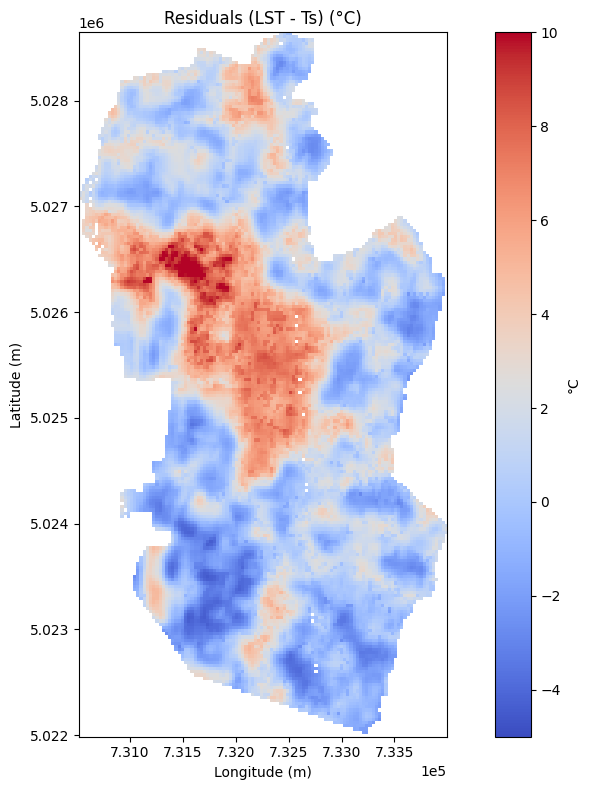

✅ Individual Residuals plot complete.


In [ ]:
# ---- Plotting Residuals (LST - Ts) Individually ----
import matplotlib.pyplot as plt
import rasterio
import numpy as np

target_date = target_date_new # Ensure consistency
diff_tif = f"/content/drive/MyDrive/EE_exports/LST_minus_Ts_{target_date}_30m_32632_Landsat.tif" # This is still 32632 from aNKMHaPJY7Gz

# First, re-read the ts_tif (now in EPSG:32632) to get the target grid profile
ts_tif_path = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif"
with rasterio.open(ts_tif_path) as ts_src:
    ts_profile = ts_src.profile
    ts_transform = ts_src.transform
    ts_crs = ts_src.crs
    ts_shape = ts_src.shape

print(f"Reading Residuals tif: {diff_tif}")

with rasterio.open(diff_tif) as src:
    diff_in = src.read(1).astype(np.float32)
    diff_transform = src.transform
    diff_crs = src.crs
    diff_nodata = src.nodata

# Reproject residuals to EPSG:32632 (target grid's CRS)
# This step ensures precise alignment with the Ts raster's grid, even if both are nominally 32632
diff_reprojected = np.full(ts_shape, np.nan, dtype=np.float32)

reproject(
    source=diff_in,
    destination=diff_reprojected,
    src_transform=diff_transform,
    src_crs=diff_crs,
    dst_transform=ts_transform,
    dst_crs=ts_crs,
    resampling=Resampling.bilinear,
    src_nodata=diff_nodata,
    dst_nodata=np.nan
)

diff_masked = np.ma.masked_invalid(diff_reprojected) # hide NaNs

plt.figure(figsize=(10, 8))
# You can adjust vmin/vmax depending on typical residual range in your AOI
im = plt.imshow(
    diff_masked,
    extent=[ts_profile['transform'].xoff, ts_profile['transform'].xoff + ts_profile['transform'].a * ts_profile['width'],
            ts_profile['transform'].yoff + ts_profile['transform'].e * ts_profile['height'], ts_profile['transform'].yoff],
    origin="upper",
    cmap="coolwarm", vmin=-5, vmax=10 # Using a similar range as in previous combined plot
)

plt.title(f"Residuals (LST - Ts) (°C)") # Updated title
plt.xlabel("Longitude (m)")
plt.ylabel("Latitude (m)")

ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.colorbar(im, label="°C")
plt.tight_layout()
plt.show()

print("✅ Individual Residuals plot complete.")

Reading Ts_tif: /content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_2024-08-09_classconst_toplayer_wc_Landsat_30.tif
Reading Residuals tif: /content/drive/MyDrive/EE_exports/LST_minus_Ts_2024-08-09_30m_32632_Landsat.tif


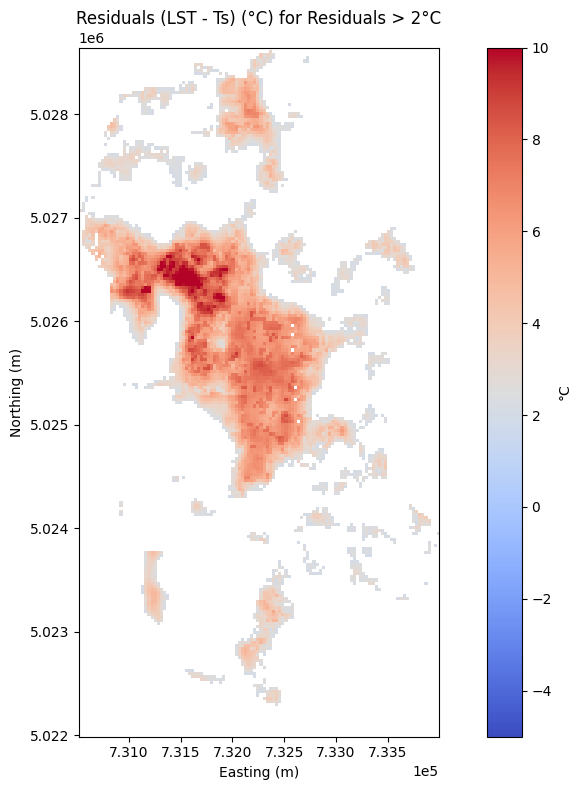

✅ Filtered residual map plotted for Residuals > 2°C.
Filtered Residual Map Stats:
  Min: 2.00°C
  Mean: 4.64°C
  Max: 13.13°C


In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# ---- Paths (using variables from previous cells) ----
target_date = target_date_new # Ensure consistency
ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif"
diff_tif = f"/content/drive/MyDrive/EE_exports/LST_minus_Ts_{target_date}_30m_32632_Landsat.tif"

print(f"Reading Ts_tif: {ts_tif}")
print(f"Reading Residuals tif: {diff_tif}")

# ---- Define a residual threshold (in Celsius) ----
residual_threshold = 2  # Adjust this value as needed

# ---- Read Ts raster (needed for alignment, but not for thresholding in this case) ----
with rasterio.open(ts_tif) as ts_src:
    Ts_data = ts_src.read(1).astype(np.float32) # Still read to get profile/shape
    ts_profile = ts_src.profile
    ts_transform = ts_src.transform
    ts_crs = ts_src.crs
    ts_shape = ts_src.shape
    ts_nodata = ts_src.nodata

# ---- Read Residuals raster ----
with rasterio.open(diff_tif) as diff_src:
    diff_data = diff_src.read(1).astype(np.float32)
    diff_profile = diff_src.profile
    diff_transform = diff_src.transform
    diff_crs = diff_src.crs
    diff_shape = diff_src.shape
    diff_nodata = diff_src.nodata

# Ensure both rasters are aligned and have the same dimensions
# (This should already be handled by previous cells, but good practice to verify)
if not (ts_shape == diff_shape and ts_transform == diff_transform and ts_crs == diff_crs):
    print("Warning: Ts and Residuals rasters do not perfectly align. Reprojecting residuals to Ts grid.")
    # If they don't align perfectly, reproject the diff_data to the ts_profile
    from rasterio.warp import reproject, Resampling
    reprojected_diff = np.full(ts_shape, np.nan, dtype=np.float32)
    reproject(
        source=diff_data,
        destination=reprojected_diff,
        src_transform=diff_transform,
        src_crs=diff_crs,
        dst_transform=ts_transform,
        dst_crs=ts_crs,
        resampling=Resampling.bilinear,
        src_nodata=diff_nodata,
        dst_nodata=np.nan
    )
    diff_data = reprojected_diff

# Handle nodata for diff
if diff_nodata is not None:
    diff_data = np.where(diff_data == diff_nodata, np.nan, diff_data)

# ---- Apply the residual threshold ----
# Create a mask where residual_data is above the threshold AND is not NaN
mask = (diff_data > residual_threshold) & (~np.isnan(diff_data))

# Apply the mask to the residual data
filtered_residuals_map = np.where(mask, diff_data, np.nan)

# Mask invalid values for plotting
filtered_residuals_masked = np.ma.masked_invalid(filtered_residuals_map)

# ---- Plot the filtered residual map ----
plt.figure(figsize=(10, 8))
im = plt.imshow(
    filtered_residuals_masked,
    extent=[ts_profile['transform'].xoff, ts_profile['transform'].xoff + ts_profile['transform'].a * ts_profile['width'],
            ts_profile['transform'].yoff + ts_profile['transform'].e * ts_profile['height'], ts_profile['transform'].yoff],
    origin="upper",
    cmap="coolwarm", vmin=-5, vmax=10 # Using a similar range as in previous combined plot
)

plt.title(f"Residuals (LST - Ts) (°C) for Residuals > {residual_threshold}°C")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")

ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

cbar = plt.colorbar(im, label="°C")
cbar.ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

print(f"✅ Filtered residual map plotted for Residuals > {residual_threshold}°C.")

# Optional: Print stats for the filtered residuals
valid_filtered_residuals = filtered_residuals_map[np.isfinite(filtered_residuals_map)]
if valid_filtered_residuals.size > 0:
    print("Filtered Residual Map Stats:")
    print(f"  Min: {np.nanmin(valid_filtered_residuals):.2f}°C")
    print(f"  Mean: {np.nanmean(valid_filtered_residuals):.2f}°C")
    print(f"  Max: {np.nanmax(valid_filtered_residuals):.2f}°C")
else:
    print("No valid residuals found after applying the residual threshold.")


✅ Comparison table ready: (16584, 21)
Residual stats (all valid points): -4.549903869628906 1.5449893474578857 13.219219207763672
Classes present: [10, 30, 40, 50, 60, 90]


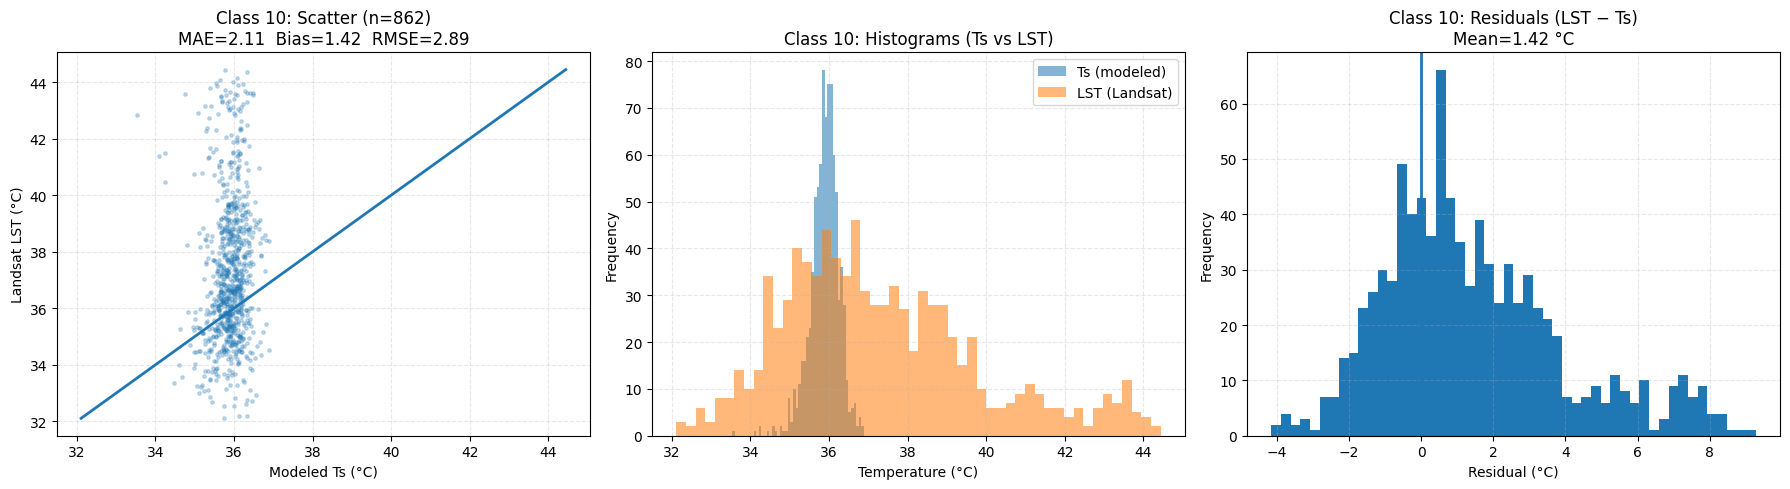

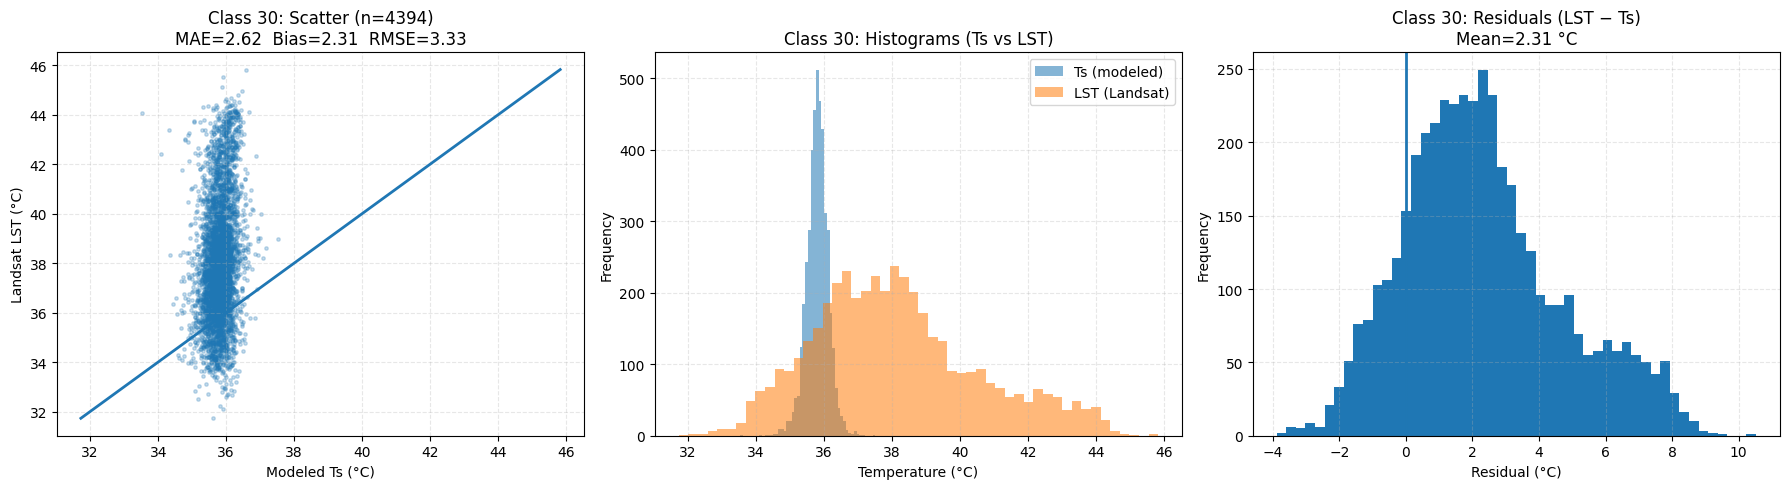

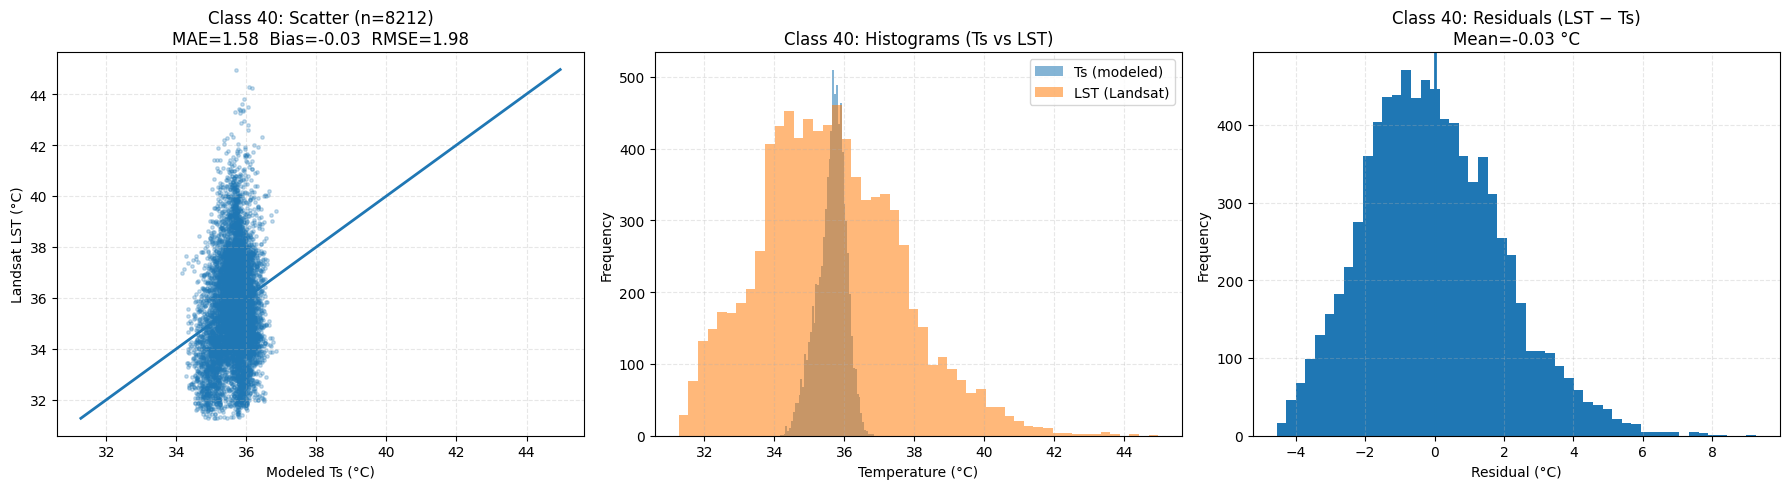

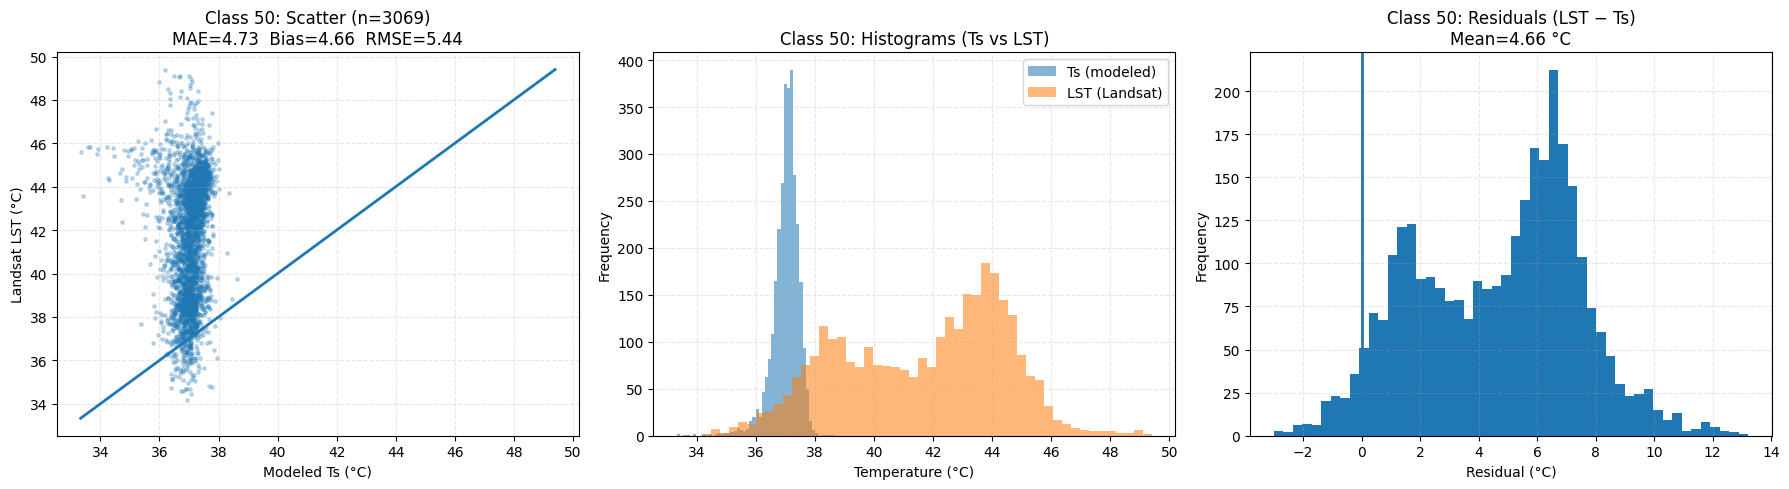

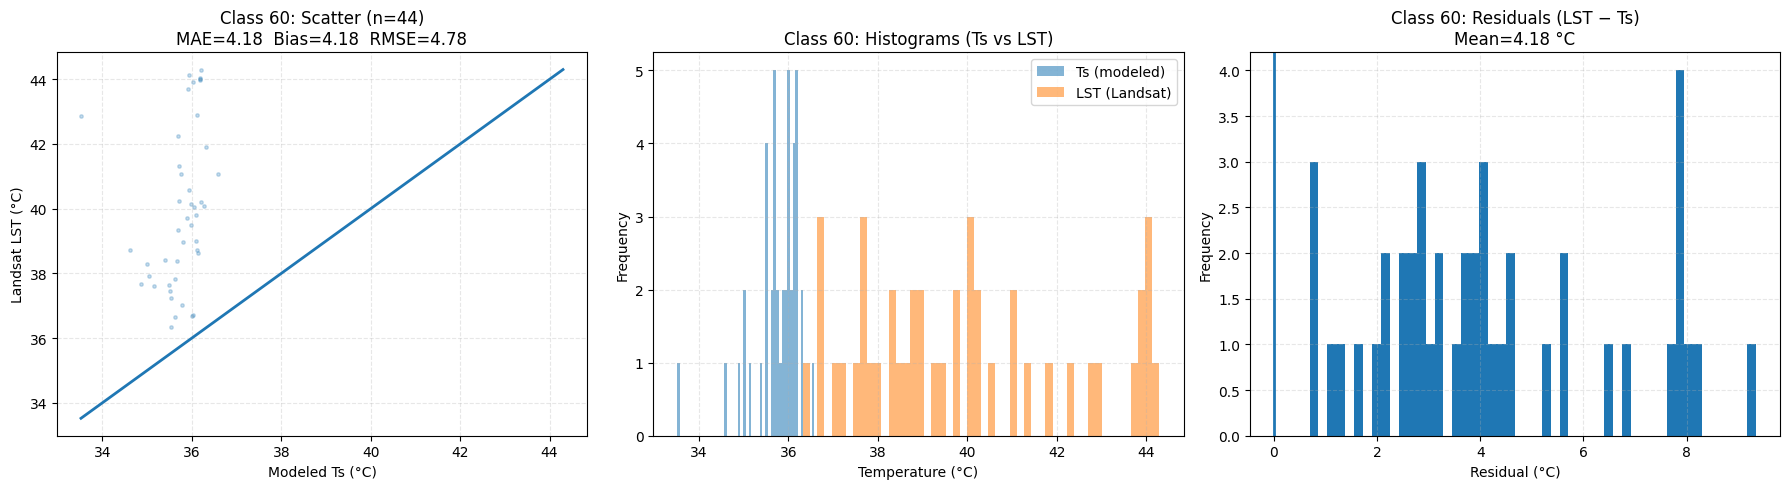

⚠️ Class 90: only 3 points → skipping plots (too few).


In [ ]:
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer
import matplotlib.pyplot as plt

# -----------------------------
# Inputs (make sure these exist)
# -----------------------------
# ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_10m_HYBRID_{target_date}_classconst_toplayer.tif"
# lst_tif = lst_10m_tif

assert 'pix' in globals(), "pix DataFrame not found."
for c in ['longitude', 'latitude', 'wc']:
    if c not in pix.columns:
        raise ValueError(f"pix must contain column: {c}")

# -----------------------------
# Open rasters
# -----------------------------
with rasterio.open(ts_tif) as ts_src, rasterio.open(lst_tif) as lst_src:

    ts_crs  = ts_src.crs
    lst_crs = lst_src.crs

    # Transformer: WGS84 -> raster CRS
    tr_ts  = Transformer.from_crs("EPSG:4326", ts_crs, always_xy=True)
    tr_lst = Transformer.from_crs("EPSG:4326", lst_crs, always_xy=True)

    # Build coordinate lists for sampling
    lon = pix['longitude'].to_numpy(np.float64)
    lat = pix['latitude'].to_numpy(np.float64)

    x_ts,  y_ts  = tr_ts.transform(lon, lat)
    x_lst, y_lst = tr_lst.transform(lon, lat)

    # Sample Ts raster at points
    Ts_samp = np.array([v[0] for v in ts_src.sample(zip(x_ts, y_ts))], dtype=np.float32)
    # Sample LST raster at points
    LST_samp = np.array([v[0] for v in lst_src.sample(zip(x_lst, y_lst))], dtype=np.float32)

    # Handle nodata → NaN
    ts_nodata  = ts_src.nodata
    lst_nodata = lst_src.nodata

    if ts_nodata is not None:
        Ts_samp = np.where(Ts_samp == ts_nodata, np.nan, Ts_samp)
    if lst_nodata is not None:
        LST_samp = np.where(LST_samp == lst_nodata, np.nan, LST_samp)

# -----------------------------
# Add sampled values to pix
# -----------------------------
pix_comp = pix.copy()
pix_comp['Ts_raster_C']  = Ts_samp
pix_comp['LST_raster_C'] = LST_samp
pix_comp['residual_C']   = pix_comp['LST_raster_C'] - pix_comp['Ts_raster_C']

# Add FinalClass column from 'wc'
pix_comp['FinalClass'] = pix_comp['wc'].astype(int)

# Drop invalid
pix_comp = pix_comp[np.isfinite(pix_comp['Ts_raster_C']) & np.isfinite(pix_comp['LST_raster_C'])].copy()

print("✅ Comparison table ready:", pix_comp.shape)
print("Residual stats (all valid points):",
      float(np.nanmin(pix_comp['residual_C'])),
      float(np.nanmean(pix_comp['residual_C'])),
      float(np.nanmax(pix_comp['residual_C'])))

# -----------------------------
# Plot per-class: scatter + parallel hist + residual hist
# -----------------------------
classes_present = sorted(pix_comp['FinalClass'].unique().tolist())
print("Classes present:", classes_present)

# Optional: if you want only 0..7
# classes_present = [c for c in classes_present if c in range(8)]

# Plot settings
BINS = 50

for c in classes_present:
    dfc = pix_comp[pix_comp['FinalClass'] == c]
    if len(dfc) < 20:
        print(f"⚠️ Class {c}: only {len(dfc)} points → skipping plots (too few).")
        continue

    Ts_c  = dfc['Ts_raster_C'].to_numpy(np.float32)
    LST_c = dfc['LST_raster_C'].to_numpy(np.float32)
    R_c   = dfc['residual_C'].to_numpy(np.float32)

    # Metrics
    mae  = float(np.nanmean(np.abs(R_c)))
    bias = float(np.nanmean(R_c))
    rmse = float(np.sqrt(np.nanmean(R_c**2)))

    # Figure: 1 row × 3 columns
    plt.figure(figsize=(18, 5))

    # ---- (1) Scatter: LST vs Ts ----
    ax1 = plt.subplot(1, 3, 1)
    ax1.scatter(Ts_c, LST_c, s=6, alpha=0.25)
    # 1:1 line
    mn = float(np.nanmin([Ts_c.min(), LST_c.min()]))
    mx = float(np.nanmax([Ts_c.max(), LST_c.max()]))
    ax1.plot([mn, mx], [mn, mx], linewidth=2)
    ax1.set_xlabel("Modeled Ts (°C)")
    ax1.set_ylabel("Landsat LST (°C)")
    ax1.set_title(f"Class {c}: Scatter (n={len(dfc)})\nMAE={mae:.2f}  Bias={bias:.2f}  RMSE={rmse:.2f}")
    ax1.grid(True, linestyle="--", alpha=0.3)

    # ---- (2) Parallel hist: LST vs Ts ----
    ax2 = plt.subplot(1, 3, 2)
    ax2.hist(Ts_c[np.isfinite(Ts_c)], bins=BINS, alpha=0.55, label="Ts (modeled)")
    ax2.hist(LST_c[np.isfinite(LST_c)], bins=BINS, alpha=0.55, label="LST (Landsat)")
    ax2.set_title(f"Class {c}: Histograms (Ts vs LST)")
    ax2.set_xlabel("Temperature (°C)")
    ax2.set_ylabel("Frequency")
    ax2.grid(True, linestyle="--", alpha=0.3)
    ax2.legend()

    # ---- (3) Residual histogram: LST - Ts ----
    ax3 = plt.subplot(1, 3, 3)
    ax3.hist(R_c[np.isfinite(R_c)], bins=BINS)
    ax3.axvline(0, linewidth=2)
    ax3.set_title(f"Class {c}: Residuals (LST − Ts)\nMean={bias:.2f} °C")
    ax3.set_xlabel("Residual (°C)")
    ax3.set_ylabel("Frequency")
    ax3.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

✅ Pixel-level comparison saved: /content/drive/MyDrive/EE_exports/pixel_comparison_LST_Ts_2024-08-09_30m_32632.csv


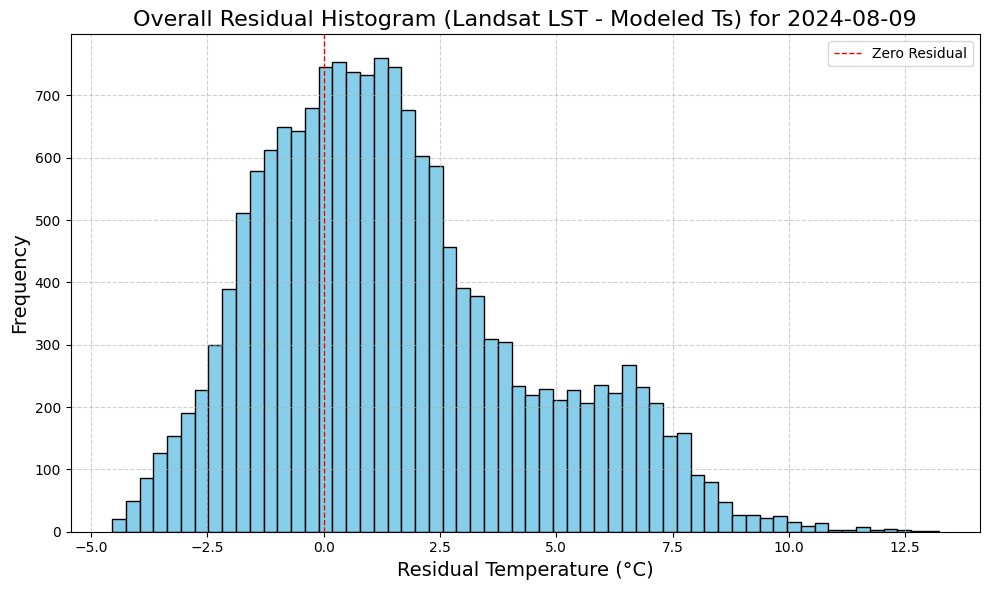

✅ Overall residual histogram plotted.


In [ ]:
# ---- Export Comparison DataFrame to CSV ----
output_comparison_csv = f"/content/drive/MyDrive/EE_exports/pixel_comparison_LST_Ts_{target_date}_30m_32632.csv"
pix_comp.to_csv(output_comparison_csv, index=False)
print(f"✅ Pixel-level comparison saved: {output_comparison_csv}")

# ---- Plot Overall Residual Histogram ----
plt.figure(figsize=(10, 6))
plt.hist(pix_comp['residual_C'].dropna(), bins=60, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero Residual')
plt.title(f"Overall Residual Histogram (Landsat LST - Modeled Ts) for {target_date}", fontsize=16)
plt.xlabel("Residual Temperature (°C)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Overall residual histogram plotted.")

Reading Ts_tif (target grid): /content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_2024-08-09_classconst_toplayer_wc_Landsat_30.tif
Reading LST_tif (source data): /content/drive/MyDrive/EE_exports/Landsat_LST_C_best_2024-08-09_30m_32632_full_corrected.tif
✅ LST reprojected to target grid (EPSG:32632).
🌡️ Reprojected LST stats: 31.287023544311523 37.488040924072266 49.1201171875


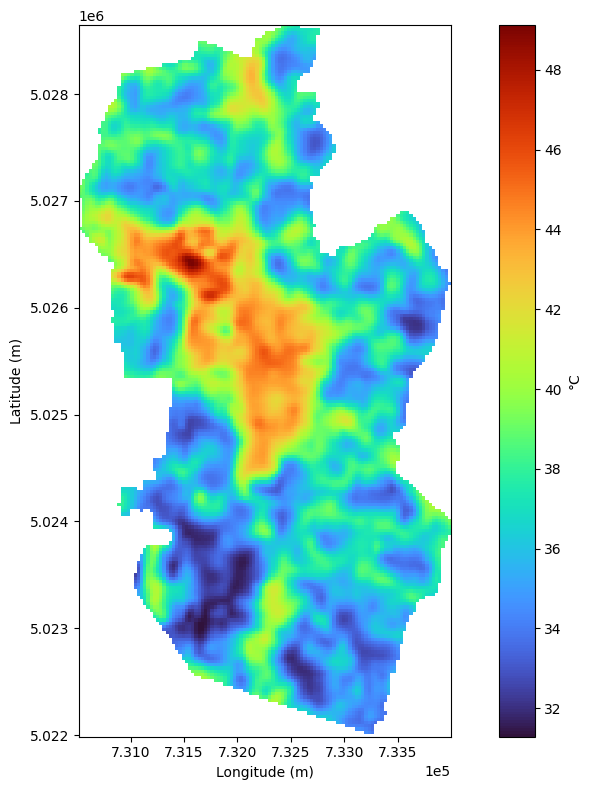

✅ Individual Modeled Ts plot complete.


In [ ]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# ---- paths (using variables from previous cells) ----
target_date = target_date_new # Ensure consistency
ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif" # Target CRS: EPSG:32632
lst_tif = lst_30m_tif # Source CRS: EPSG:32632

print(f"Reading Ts_tif (target grid): {ts_tif}")
print(f"Reading LST_tif (source data): {lst_tif}")

# ---- Read Ts raster (to get target grid profile) ----
with rasterio.open(ts_tif) as ts_src:
    ts_profile = ts_src.profile
    ts_transform = ts_src.transform
    ts_crs = ts_src.crs
    ts_shape = ts_src.shape
    ts_nodata = ts_src.nodata

# ---- Read LST raster ----
with rasterio.open(lst_tif) as lst_src:
    LST_in = lst_src.read(1).astype(np.float32)
    lst_transform = lst_src.transform
    lst_crs = lst_src.crs
    lst_nodata = lst_src.nodata

# ---- Reproject LST onto the Ts grid (EPSG:32632) ----
LST_reprojected = np.full(ts_shape, np.nan, dtype=np.float32)

reproject(
    source=LST_in,
    destination=LST_reprojected,
    src_transform=lst_transform,
    src_crs=lst_crs,
    dst_transform=ts_transform,
    dst_crs=ts_crs,
    resampling=Resampling.bilinear,
    src_nodata=lst_nodata,
    dst_nodata=np.nan # Use NaN for nodata in the reprojected array
)

# ---- Mask nodata values if any ----
LST_masked = np.ma.masked_invalid(LST_reprojected)

print("✅ LST reprojected to target grid (EPSG:32632).") # Updated CRS in print statement
print("🌡️ Reprojected LST stats:",
      float(np.nanmin(LST_reprojected)),
      float(np.nanmean(LST_reprojected)),
      float(np.nanmax(LST_reprojected)))

# ---- Plot the LST image ----
plt.figure(figsize=(10, 8))
im = plt.imshow(
    LST_masked,
    extent=[ts_profile['transform'].xoff, ts_profile['transform'].xoff + ts_profile['transform'].a * ts_profile['width'],
            ts_profile['transform'].yoff + ts_profile['transform'].e * ts_profile['height'], ts_profile['transform'].yoff],
    origin="upper",
    cmap="turbo"
)

#plt.title(f"Landsat LST (°C) — {target_date} (EPSG:32632)") # Updated title
plt.xlabel("Longitude (m)")
plt.ylabel("Latitude (m)")
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

cbar = plt.colorbar(im, label="°C")
cbar.ax.tick_params(labelsize=10) # Set the fontsize for the colorbar's tick values
plt.tight_layout()
plt.show()

print("✅ Individual Modeled Ts plot complete.")

Reading Ts_tif: /content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_2024-08-09_classconst_toplayer_wc_Landsat_30.tif


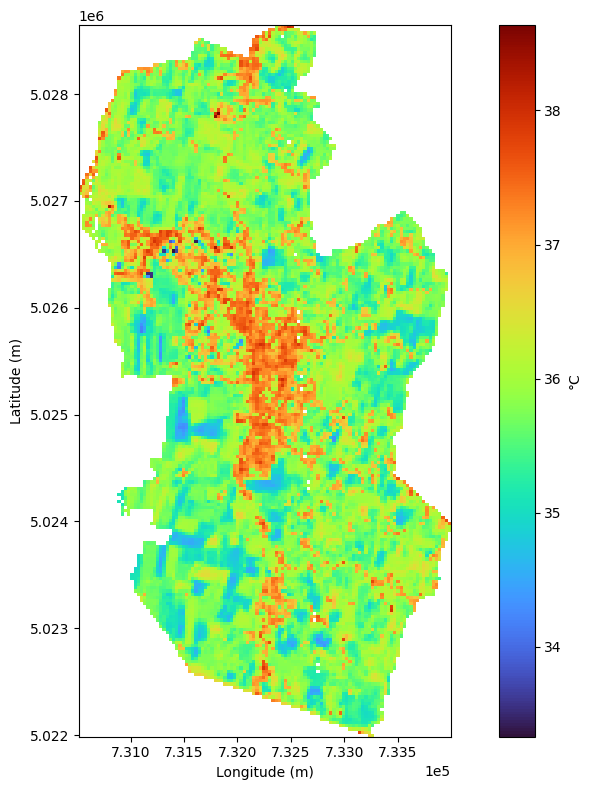

✅ Individual Modeled Ts plot complete.


In [ ]:
# ---- Plotting Modeled Ts Individually ----
import matplotlib.pyplot as plt
import rasterio
import numpy as np

target_date = target_date_new # Ensure consistency
ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif" # Updated filename

print(f"Reading Ts_tif: {ts_tif}")

with rasterio.open(ts_tif) as src:
    Ts_data = src.read(1)
    bounds = src.bounds

Ts_masked = np.ma.masked_invalid(Ts_data)   # hide NaNs

plt.figure(figsize=(10, 8))
im = plt.imshow(
    Ts_masked,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    origin="upper",
    cmap="turbo"
)

#plt.title(f"Modeled Surface Temperature (Ts) (°C) — {target_date}") # Updated title
plt.xlabel("Longitude (m)")
plt.ylabel("Latitude (m)")

ax = plt.gca()
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

cbar = plt.colorbar(im, label="°C")
cbar.ax.tick_params(labelsize=10) # Set the fontsize for the colorbar's tick values
plt.tight_layout()
plt.show()

print("✅ Individual Modeled Ts plot complete.")

Reading Ts_tif: /content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_2024-08-09_classconst_toplayer_wc_Landsat_30.tif
Reading LST_tif: /content/drive/MyDrive/EE_exports/Landsat_LST_C_best_2024-08-09_30m_32632_full_corrected.tif


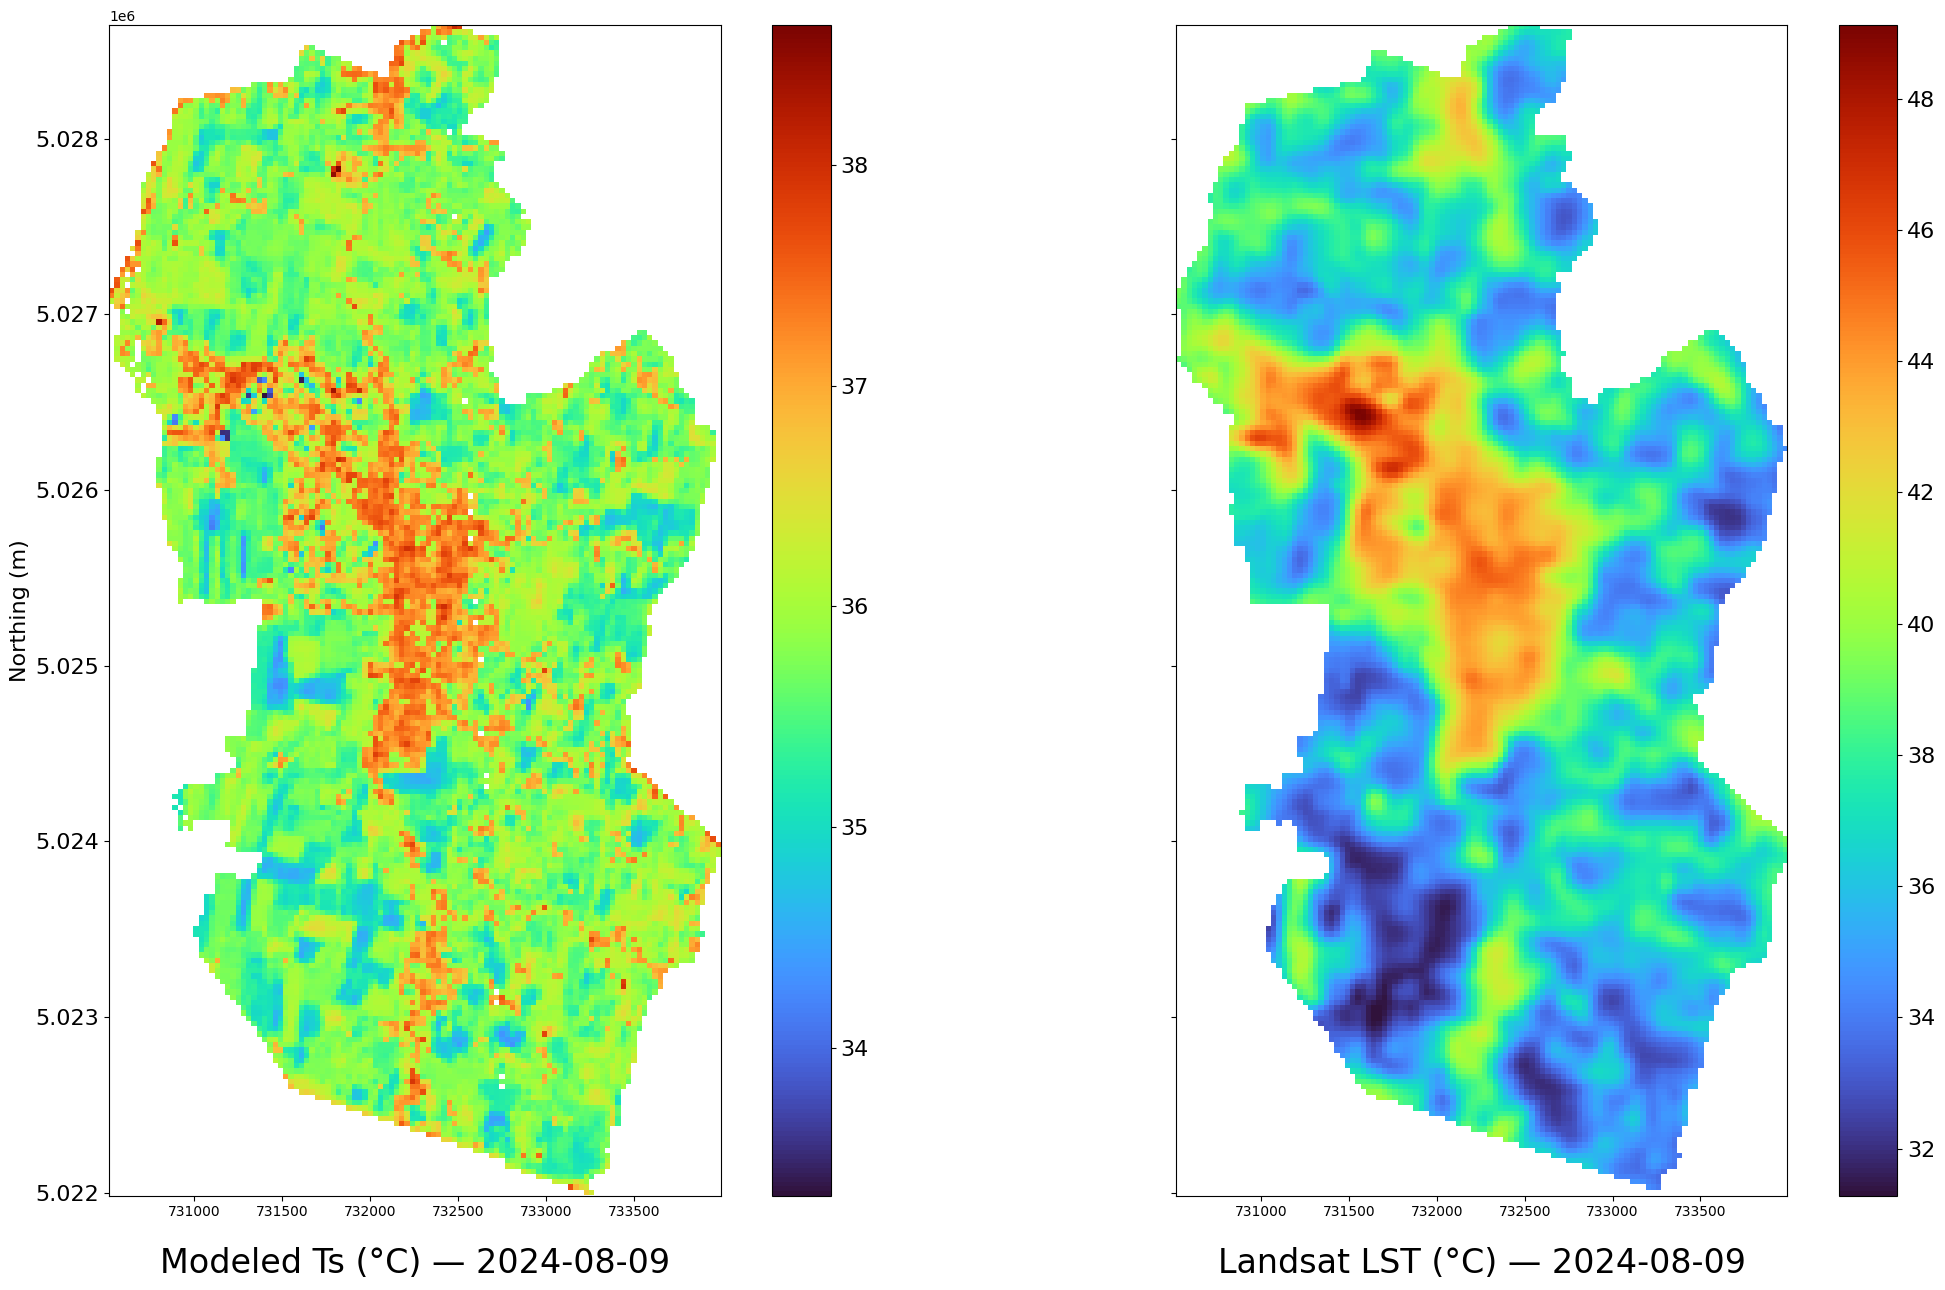

✅ Individual Modeled Ts and LST plots complete.


In [ ]:
# ---- Plotting Modeled Ts and LST Individually (Side-by-side) ----
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling

target_date = target_date_new # Ensure consistency
ts_tif  = f"/content/drive/MyDrive/EE_exports/Ts_model_30m_HYBRID_{target_date}_classconst_toplayer_wc_Landsat_30.tif"
lst_tif = lst_30m_tif

print(f"Reading Ts_tif: {ts_tif}")
print(f"Reading LST_tif: {lst_tif}")

# ---- Read Ts raster (template grid) ----
with rasterio.open(ts_tif) as ts_src:
    Ts_data = ts_src.read(1).astype(np.float32)
    ts_profile = ts_src.profile
    ts_transform = ts_src.transform
    ts_crs = ts_src.crs
    ts_shape = Ts_data.shape
    ts_nodata = ts_src.nodata

# ---- Read LST raster ----
with rasterio.open(lst_tif) as lst_src:
    LST_in = lst_src.read(1).astype(np.float32)
    lst_transform = lst_src.transform
    lst_crs = lst_src.crs
    lst_nodata = lst_src.nodata

# ---- Reproject LST onto the Ts grid (EPSG:32632) ----
LST_reprojected = np.full(ts_shape, np.nan, dtype=np.float32)

reproject(
    source=LST_in,
    destination=LST_reprojected,
    src_transform=lst_transform,
    src_crs=lst_crs,
    dst_transform=ts_transform,
    dst_crs=ts_crs,
    resampling=Resampling.bilinear,
    src_nodata=lst_nodata,
    dst_nodata=np.nan # Use NaN for nodata in the reprojected array
)

# ---- Mask nodata values if any ----
Ts_masked  = np.ma.masked_invalid(Ts_data)   # hide NaNs
LST_masked = np.ma.masked_invalid(LST_reprojected) # hide NaNs

plt.figure(figsize=(24, 13)) # Adjust figsize for two plots
plt.subplots_adjust(wspace=0.1, hspace=0) # Add some horizontal space

# ---- Plot Modeled Ts ----
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
im_ts = plt.imshow(
    Ts_masked,
    extent=[ts_profile['transform'].xoff, ts_profile['transform'].xoff + ts_profile['transform'].a * ts_profile['width'],
            ts_profile['transform'].yoff + ts_profile['transform'].e * ts_profile['height'], ts_profile['transform'].yoff],
    origin="upper",
    cmap="turbo"
)
plt.xlabel(f"Modeled Ts (°C) — {target_date}", fontsize=24, labelpad=20)
plt.ylabel("Northing (m)", fontsize=16)
plt.tick_params(axis='y', labelsize=16)
cbar_ts = plt.colorbar(im_ts, fraction=0.08, pad=0.04)
cbar_ts.ax.tick_params(labelsize=16)

# ---- Plot Landsat LST ----
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
im_lst = plt.imshow(
    LST_masked,
    extent=[ts_profile['transform'].xoff, ts_profile['transform'].xoff + ts_profile['transform'].a * ts_profile['width'],
            ts_profile['transform'].yoff + ts_profile['transform'].e * ts_profile['height'], ts_profile['transform'].yoff],
    origin="upper",
    cmap="turbo"
)
plt.xlabel(f"Landsat LST (°C) — {target_date}", fontsize=24, labelpad=20)
plt.tick_params(axis='y', labelleft=False) # Hide y-axis labels for second plot
cbar_lst = plt.colorbar(im_lst, fraction=0.08, pad=0.04)
cbar_lst.ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

print("✅ Individual Modeled Ts and LST plots complete.")